Features Dataset Head:
        BMI   GenHlth  MentHlth  PhysHlth       Age    Income  HighBP_0.0  \
0 -0.511946 -0.479079 -0.430031 -0.487165 -0.010758  0.940421         0.0   
1  0.397382  0.456922 -0.430031 -0.487165  1.300124 -0.024525         0.0   
2 -0.208837  0.456922 -0.430031 -0.487165  0.972404  0.940421         0.0   
3 -0.815055  0.456922  3.614406 -0.487165  0.644683 -0.024525         1.0   
4 -0.966610  0.456922 -0.430031 -0.487165 -1.649361 -0.024525         1.0   

   HighBP_1.0  HighChol_0.0  HighChol_1.0  ...  HvyAlcoholConsump_0.0  \
0         1.0           1.0           0.0  ...                    1.0   
1         1.0           0.0           1.0  ...                    1.0   
2         1.0           0.0           1.0  ...                    1.0   
3         0.0           1.0           0.0  ...                    1.0   
4         0.0           1.0           0.0  ...                    1.0   

   HvyAlcoholConsump_1.0  DiffWalk_0.0  DiffWalk_1.0  Education_1.0  \
0   

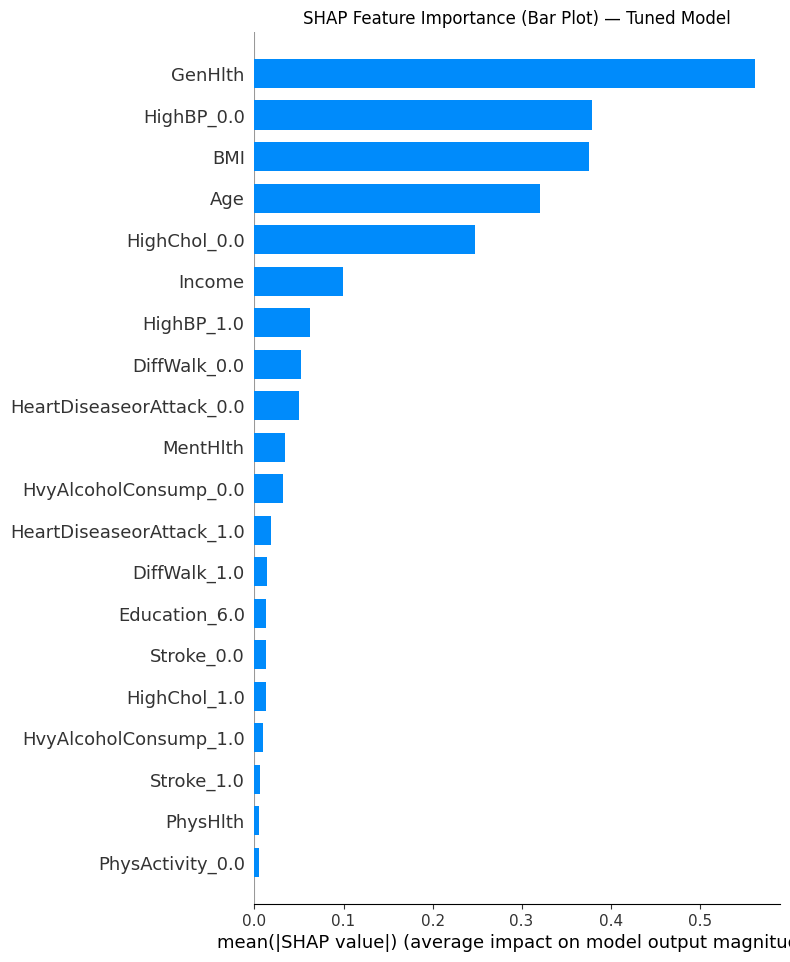

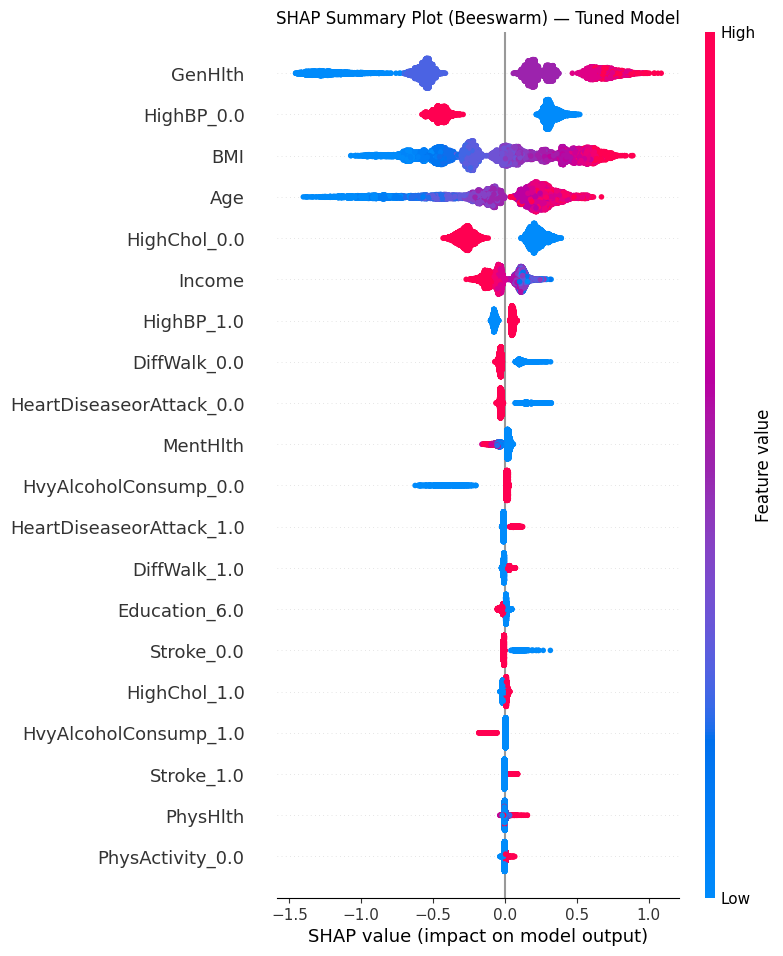


Demonstrating a SHAP Force Plot for a single prediction (first test sample):


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

# --- 1. Load your actual diabetes datasets ---
features_dataset_path = 'undersampled_features.csv'
target_dataset_path = 'undersampled_target.csv'
target_column_name = 'Diabetes_binary'

try:
    X = pd.read_csv(features_dataset_path)
except FileNotFoundError:
    print(f"Error: Features dataset not found at {features_dataset_path}.")
    raise

try:
    y_df = pd.read_csv(target_dataset_path)
    if target_column_name:
        y = y_df[target_column_name]
    else:
        y = y_df.iloc[:, 0]
except FileNotFoundError:
    print(f"Error: Target dataset not found at {target_dataset_path}.")
    raise
except KeyError:
    print(f"Error: Target column '{target_column_name}' not found.")
    raise

print("Features Dataset Head:")
print(X.head())
print(f"\nTarget distribution:\n{y.value_counts(normalize=True)}")

# --- 2. Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTraining data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

# --- 3. Hyperparameter tuning with RandomizedSearchCV (optimizing accuracy) --- #
print("\nRunning RandomizedSearchCV for XGBoost (scoring=accuracy)...")

param_dist = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
}

base_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
)

search = RandomizedSearchCV(
    base_model,
    param_distributions=param_dist,
    n_iter=30,
    scoring='accuracy',   # tuning target as instructed
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42,
)

search.fit(X_train, y_train)

print("\nBest hyperparameters found:")
print(search.best_params_)
print(f"Best CV accuracy: {search.best_score_:.4f}")

model = search.best_estimator_  # final tuned model
print("\nXGBoost Model Training (with tuning) Complete.")

# --- 4. Evaluate the tuned model on the held-out test set --- #
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nTuned Model Accuracy on Test Set: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# --- 5. Explain the tuned model with SHAP --- #
print("\nCalculating SHAP values...")
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
print("SHAP values calculated.")

# --- 6. Visualize SHAP results --- #
print("\nGenerating SHAP summary plot...")
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Bar Plot) — Tuned Model")
plt.show()

shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot (Beeswarm) — Tuned Model")
plt.show()

print("\nDemonstrating a SHAP Force Plot for a single prediction (first test sample):")
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0], X_test.iloc[0])

### Visualize Evaluation Results

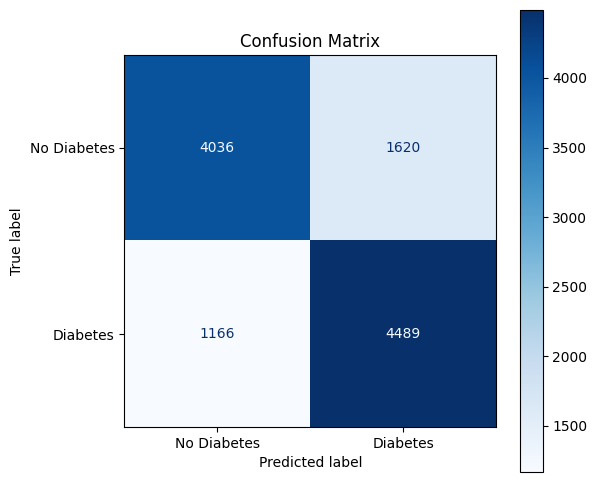

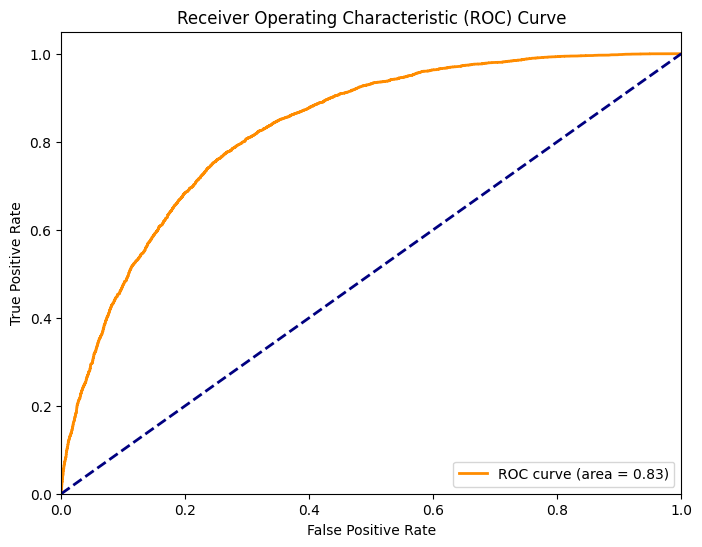

In [ ]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes', 'Diabetes'])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# ROC Curve
y_pred_proba = model.predict_proba(X_test)[:, 1] # Probability of positive class
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

fig = plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

### Download the Trained Model

In [ ]:
import joblib

# Define the filename for the model
model_filename = 'xgboost_diabetes_model.joblib'

# Save the trained model to a file
joblib.dump(model, model_filename)

print(f"Model saved successfully as '{model_filename}'")

Model saved successfully as 'xgboost_diabetes_model.joblib'
